In [355]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.decomposition import PCA
import seaborn as sns


### load 

In [356]:
df_features = pd.read_csv('Train_call.txt', sep=None, engine='python')
df_labels = pd.read_csv('Train_clinical.txt', sep=None, engine='python')

### Class imbalance

HER2+: 32
HR+: 36
Triple Neg: 32


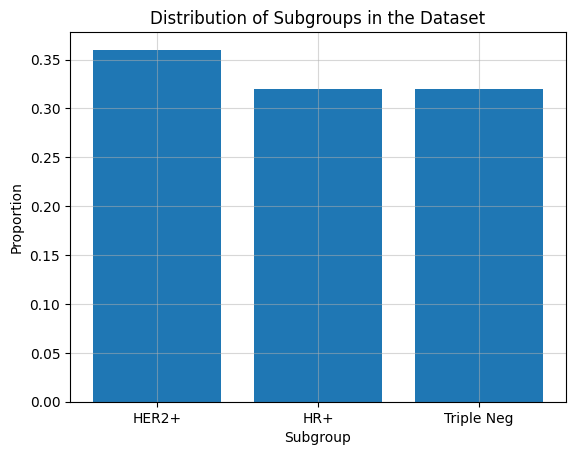

In [357]:
labels = df_labels["Subgroup"].unique()

for label in labels:
    count_label = df_labels["Subgroup"].value_counts()[label]
    print(f"{label}: {count_label}")


plt.Figure(figsize=(10, 6))
plt.grid(alpha=0.5)

plt.bar(labels, df_labels["Subgroup"].value_counts()/len(df_labels))
plt.xlabel("Subgroup")
plt.ylabel("Proportion")
plt.title("Distribution of Subgroups in the Dataset")
plt.show()  

### Feature correlation 

In [358]:
df_features = df_features.drop(columns=['Chromosome', 'Start', 'End', 'Nclone'] )
print(f"Shape before dropping duplicates: {df_features.shape}")
df_features = df_features.drop_duplicates()
print(f"Shape after dropping duplicates: {df_features.shape}")

Shape before dropping duplicates: (2834, 100)
Shape after dropping duplicates: (2764, 100)


Original number of features: 2764
Number of components needed for 99.9999% variance: 99
Total variance explained: 1.0000
          0         1         2         3          4          5          6   \
0  -0.807304 -3.944621  1.238874 -7.780684  -9.686364 -11.478328  12.443480   
1  -5.827407  5.318843  4.648659  8.211117   3.083086  -3.919238   3.709456   
2 -13.452016 -9.178867  5.565449  4.261317  12.189517  -4.720080  -4.381639   
3 -15.504811  9.418339  8.406689  8.712798  -3.414217   0.307797 -16.770975   
4  -3.089099 -1.157272 -5.730106  1.847097   7.707243   7.229976  -4.114542   

         7         8          9   ...        89        90        91        92  \
0 -4.476463 -4.507660  10.026957  ... -0.094405  0.380528 -0.177994  0.060323   
1 -0.844729  0.325542  -2.128287  ... -0.151415  0.827482 -0.618368  0.019613   
2 -1.235540  1.208021  -7.509949  ...  0.056416  0.427031  0.279773  0.291948   
3  5.777810  0.042031   4.054528  ... -0.140834  0.922354 -0.322193  0.232807   

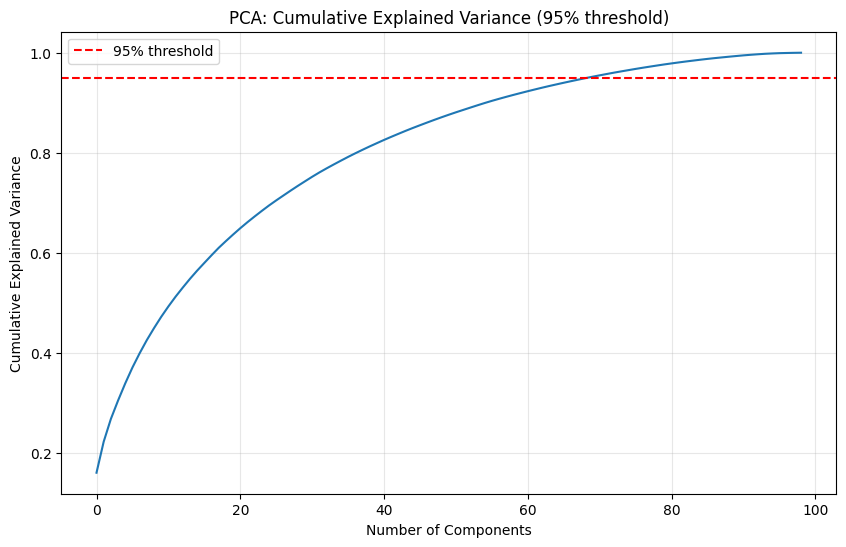

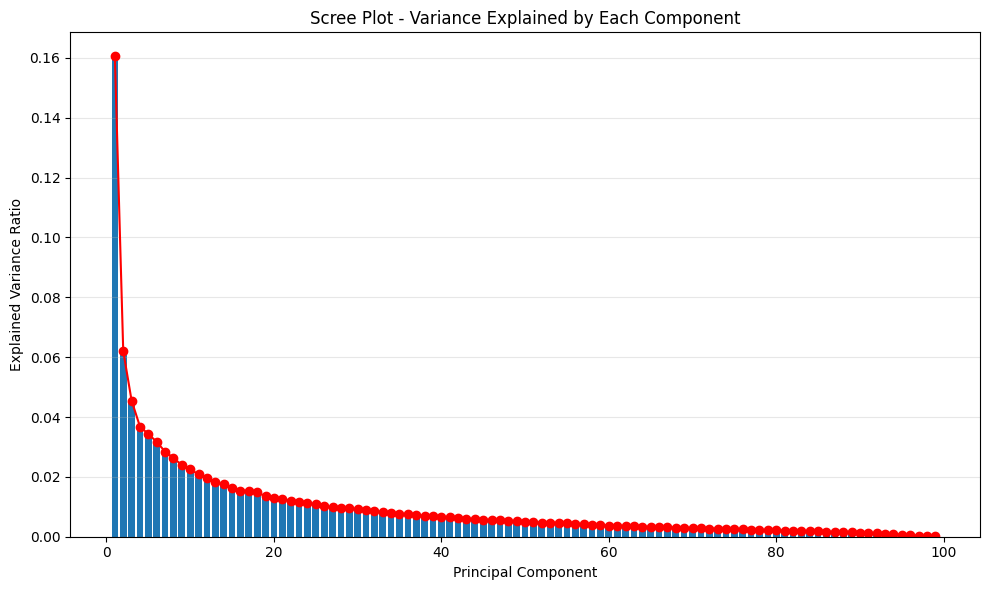

In [359]:
# PCA to retain 95% of variance

def fit_pca(train, test=None, variance_threshold=0.95):
    pca = PCA(n_components=variance_threshold)
    df_pca = pca.fit_transform(train)
    df_pca_test = pca.transform(test) if test is not None else None

    print(f"Original number of features: {train.shape[1]}")
    print(f"Number of components needed for {variance_threshold*100}% variance: {pca.n_components_}")
    print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")
    print(pd.DataFrame(df_pca).head())
    return pca, df_pca, df_pca_test


pca, df_pca, _ = fit_pca(df_features.T, variance_threshold=.999999) # Adjusted to retain 99.999% variance
# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Cumulative Explained Variance (95% threshold)")
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Scree plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'ro-')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot - Variance Explained by Each Component")
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



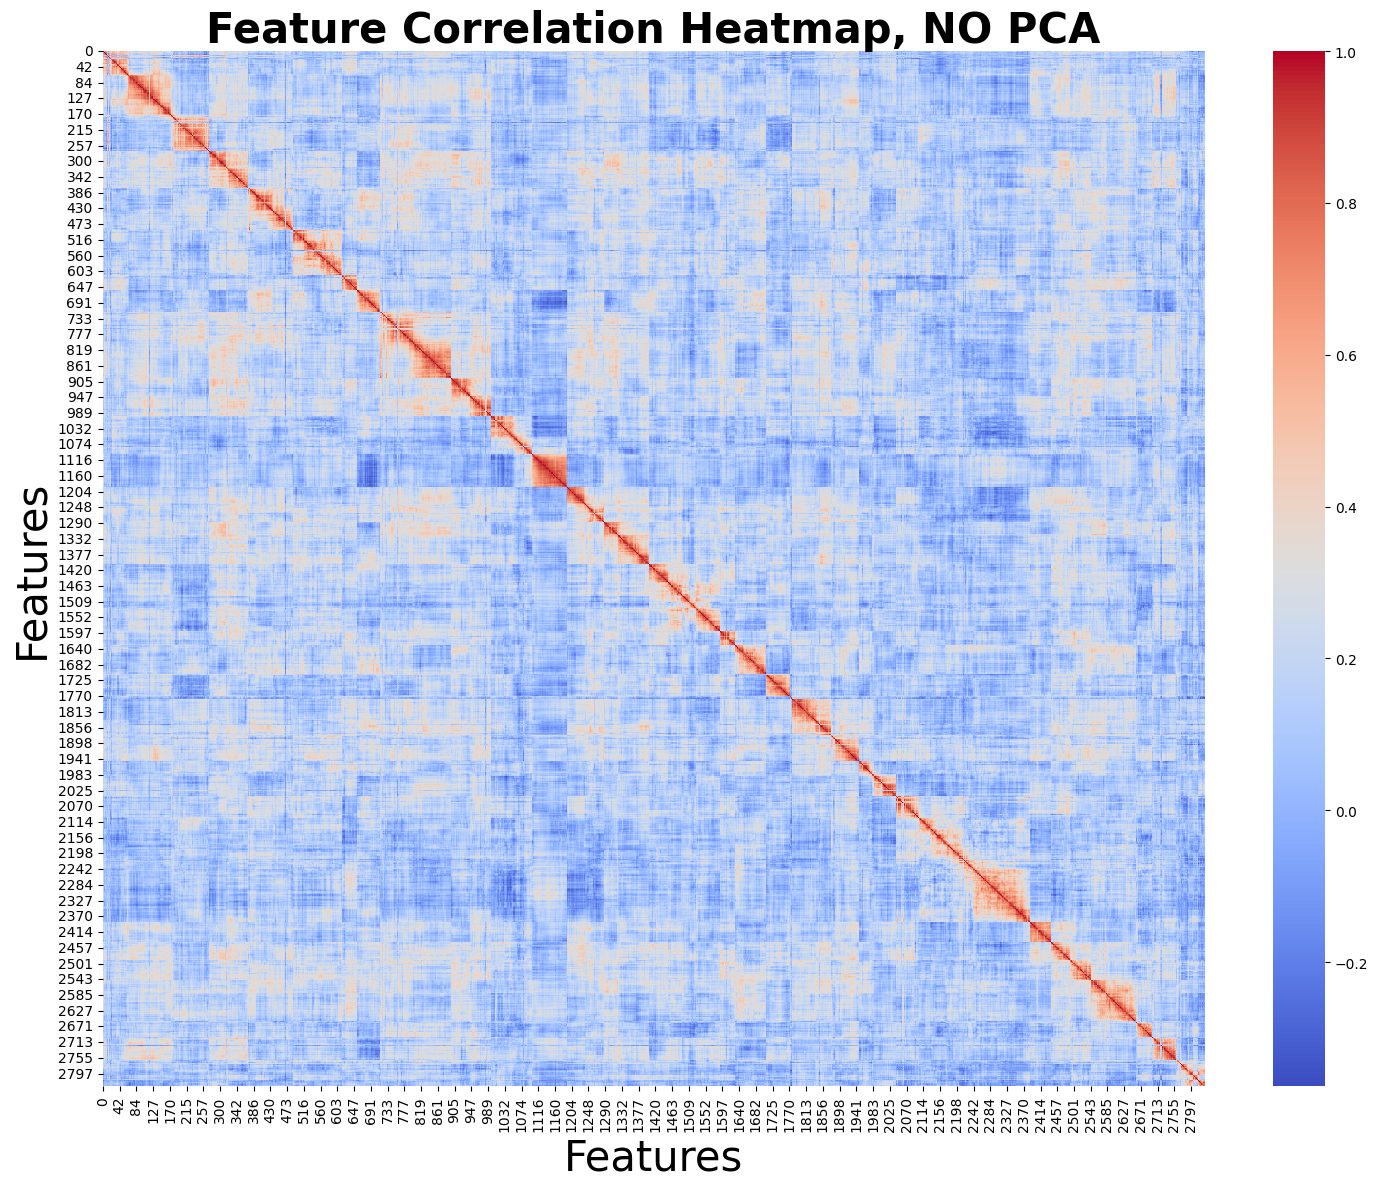

In [360]:
correlation_matrix = df_features.T.corr()

plt.figure(figsize=(15, 12))

# Create heatmap
sns.heatmap(correlation_matrix, cmap='coolwarm')

plt.title("Feature Correlation Heatmap, NO PCA", fontsize=30, fontweight='bold')
plt.xlabel("Features", fontsize=30)
plt.ylabel("Features", fontsize=30) 
plt.tight_layout()
plt.show()
plt.close()


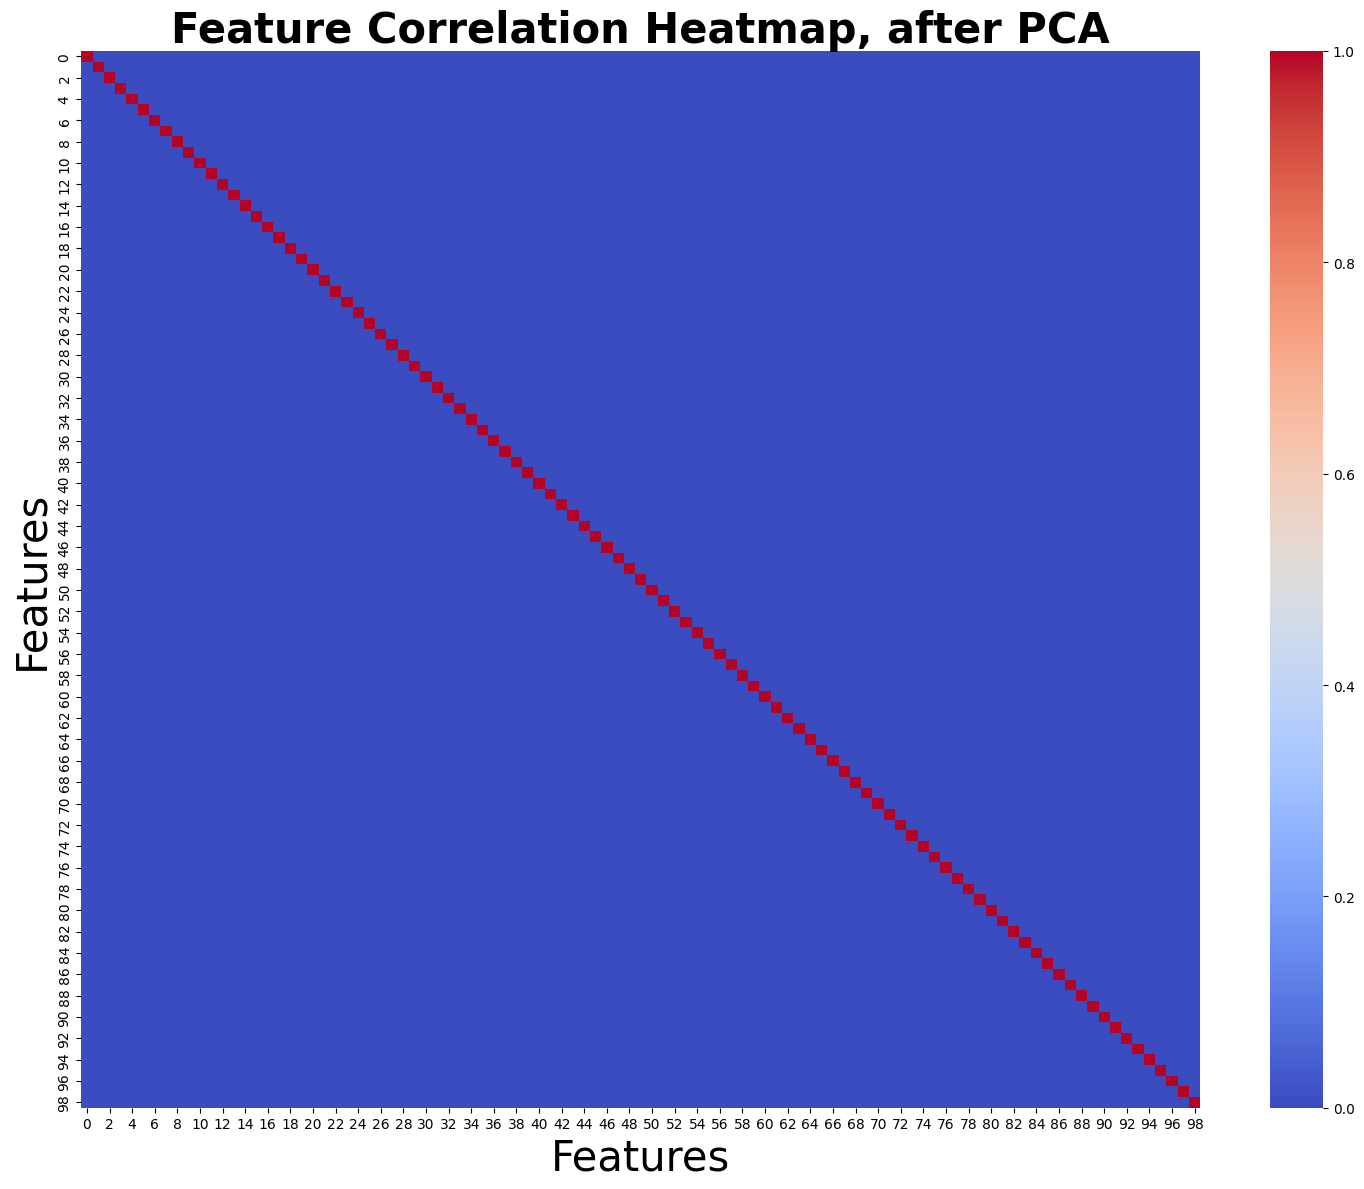

In [361]:

correlation_matrix = pd.DataFrame(df_pca).corr()

plt.figure(figsize=(15, 12))

# Create heatmap
sns.heatmap(correlation_matrix, cmap='coolwarm')

plt.title("Feature Correlation Heatmap, after PCA", fontsize=30, fontweight='bold')
plt.xlabel("Features", fontsize=30)
plt.ylabel("Features", fontsize=30) 
plt.tight_layout()
plt.show()
plt.close()


### random forrest classifier

In [362]:
df_features = pd.read_csv('Train_call.txt', sep=None, engine='python')
df_labels = pd.read_csv('Train_clinical.txt', sep=None, engine='python')
df_features = df_features.drop_duplicates()


In [ ]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier



### Merging files ##### 
X_joined = df_features.T.reset_index().rename(columns={'index': 'Sample'}).merge(df_labels, how='inner', on='Sample')

# Split  training and testing 
X = X_joined.drop(columns=['Subgroup', 'Sample'])
y = X_joined['Subgroup']

class_labels = np.sort(y.unique())

#### DIFFERENT MODELS FOR CV ####

def run_train_val_RF(X_train, y_train, X_val, y_val, use_pca=False, pca_variance_threshold=0.50):
    if use_pca: 
        # Fit PCA only on training fold
        pca = PCA(n_components=pca_variance_threshold)
        X_train = pca.fit_transform(X_train)
        X_val = pca.transform(X_val)  
        
    rf_cv = RandomForestClassifier(n_estimators=100,n_jobs=-1)
    rf_cv.fit(X_train, y_train)
    y_pred = rf_cv.predict(X_val)

    cm = confusion_matrix(y_val, y_pred, labels=class_labels, normalize='true')
    return cm


def run_train_val_knn(X_train, y_train, X_val, y_val, use_pca=False, pca_variance_threshold=0.50):
    if use_pca: 
        # Fit PCA only on training fold
        pca = PCA(n_components=pca_variance_threshold)
        X_train = pca.fit_transform(X_train)
        X_val = pca.transform(X_val)  
        
    knn_cv = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn_cv.fit(X_train, y_train)
    y_pred = knn_cv.predict(X_val)

    cm = confusion_matrix(y_val, y_pred, labels=class_labels, normalize='true')
    return cm

def run_train_val_svm(X_train, y_train, X_val, y_val, use_pca=False, pca_variance_threshold=0.50):
    if use_pca: 
        # Fit PCA only on training fold
        pca = PCA(n_components=pca_variance_threshold)
        X_train = pca.fit_transform(X_train)
        X_val = pca.transform(X_val)  
        
    svm_cv = SVC(kernel='rbf', random_state=42)
    svm_cv.fit(X_train, y_train)
    y_pred = svm_cv.predict(X_val)

    cm = confusion_matrix(y_val, y_pred, labels=class_labels, normalize='true')
    return cm

def run_train_val_neural_net(X_train, y_train, X_val, y_val, use_pca=False, pca_variance_threshold=0.50):
    if use_pca: 
        # Fit PCA only on training fold
        pca = PCA(n_components=pca_variance_threshold)
        X_train = pca.fit_transform(X_train)
        X_val = pca.transform(X_val)  
        
    nn_cv = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
    nn_cv.fit(X_train, y_train)
    y_pred = nn_cv.predict(X_val)

    cm = confusion_matrix(y_val, y_pred, labels=class_labels, normalize='true')
    return cm

### CV PIPELINE #### 

def run_cv(model, X_train, y_train, use_pca=False, splits = 10, pca_variance_threshold=0.50):
    cv_conf_matrices = []
    kfold = KFold(n_splits=splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kfold.split(X_train):

        X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        if model == "RF":
            cm = run_train_val_RF(X_cv_train, y_cv_train, X_cv_val, y_cv_val, use_pca, pca_variance_threshold)
        elif model == "knn":
            cm = run_train_val_knn(X_cv_train, y_cv_train, X_cv_val, y_cv_val, use_pca, pca_variance_threshold)
        elif model == "svm":
            cm = run_train_val_svm(X_cv_train, y_cv_train, X_cv_val, y_cv_val, use_pca, pca_variance_threshold)
        elif model == "neural_net":
            cm = run_train_val_neural_net(X_cv_train, y_cv_train, X_cv_val, y_cv_val, use_pca, pca_variance_threshold)
        
        cv_conf_matrices.append(cm)
    avg_conf_matrix = np.mean(cv_conf_matrices, axis=0)
    return avg_conf_matrix

### PLOTTING FUNCTION ###

def plotter(avg_conf_df):
    # Plot average confusion matrix as rates
    plt.figure(figsize=(8, 6))
    annot_labels = (avg_conf_df * 100).round(1).astype(str) + '%'
    sns.heatmap(
        avg_conf_df,
        annot=annot_labels,
        fmt='',
        cmap='Blues',
        vmin=0, vmax=1,
        cbar_kws={'label': 'Rate'}
    )
    plt.title("Average Confusion Matrix (10-fold CV) - Rates")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()



C:\Users\imaan\AppData\Local\Temp\ipykernel_13440\1550213765.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


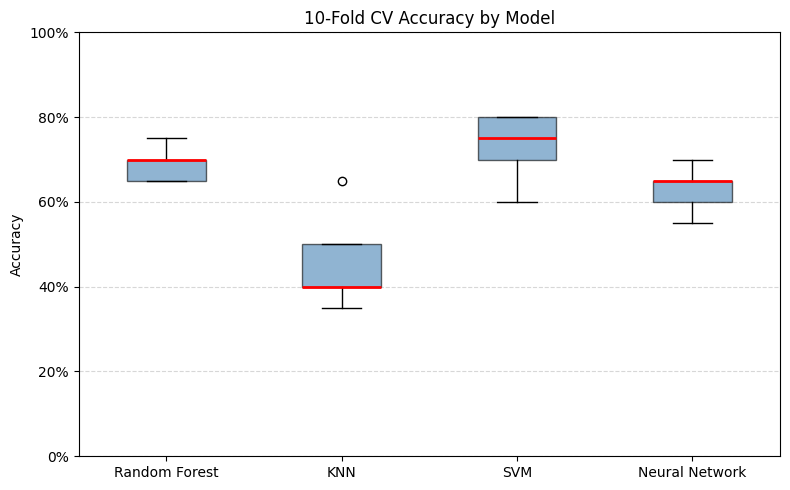

In [385]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

def run_cv_accuracy(model, X_train, y_train, use_pca=False, splits=5, pca_variance_threshold=0.50):
    """Same as run_cv but returns per-fold accuracy scores instead of avg confusion matrix."""
    fold_accuracies = []
    kfold = KFold(n_splits=splits, shuffle=True, random_state=42)


    for train_idx, val_idx in kfold.split(X_train):
        X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        


        X_tr, X_vl = X_cv_train.copy(), X_cv_val.copy()

    
        if use_pca:
            pca = PCA(n_components=pca_variance_threshold)
            X_tr = pca.fit_transform(X_tr)
            X_vl = pca.transform(X_vl)

        clf_map = {
            "RF":         RandomForestClassifier(n_estimators=100, n_jobs=-1),
            "knn":        KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
            "svm":        SVC(kernel='sigmoid'),
            "neural_net": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300),
        }
        clf = clf_map[model]
        clf.fit(X_tr, y_cv_train)
        y_pred = clf.predict(X_vl)
        fold_accuracies.append(accuracy_score(y_cv_val, y_pred))

    return fold_accuracies


# --- Collect results for all models ---
models = ["RF", "knn", "svm", "neural_net"]
model_labels = ["Random Forest", "KNN", "SVM", "Neural Network"]

results = {}
for m in models:
    results[m] = run_cv_accuracy(m, X, y, use_pca=False)

# --- Boxplot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [results[m] for m in models],
    labels=model_labels,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2),
)
ax.set_title("10-Fold CV Accuracy by Model")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




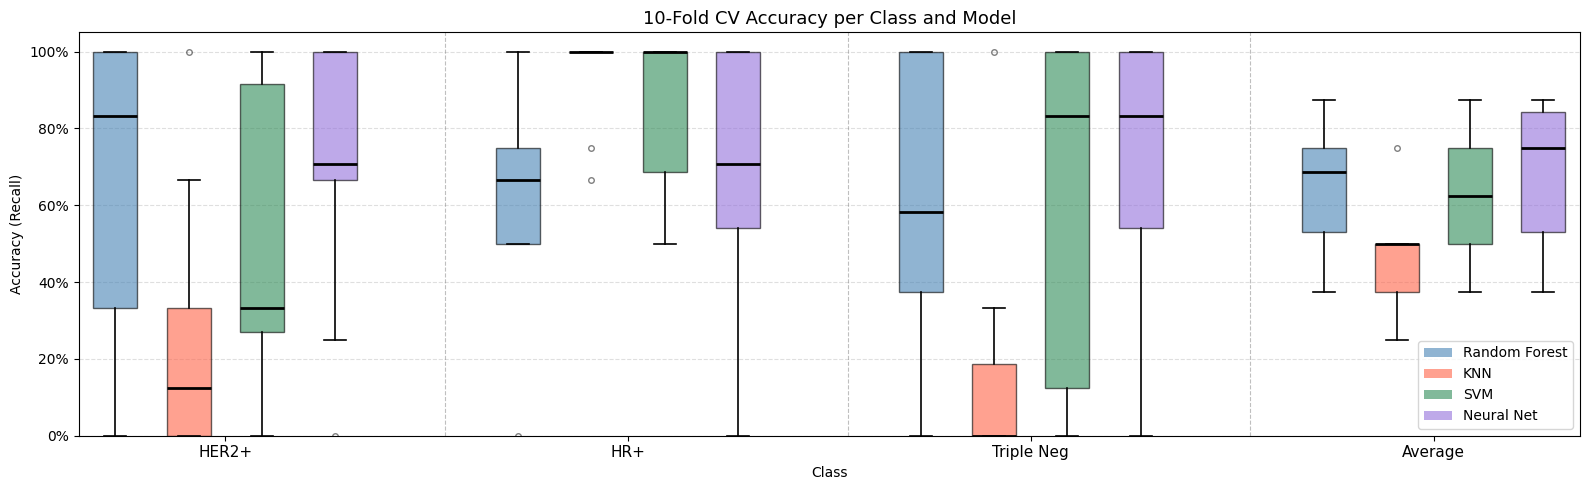

In [ ]:

def run_cv_class_accuracy(model, X_train, y_train, use_pca=False, splits=10, pca_variance_threshold=0.50):
    """
    Returns a dict: { class_label: [fold_accuracies], ..., 'Average': [fold_accuracies] }
    Per-class accuracy = recall (diagonal of row-normalized CM).
    """
    kfold = KFold(n_splits=splits, shuffle=True, random_state=42)

    # fold_scores[label] = list of per-fold accuracy for that class
    fold_scores = {label: [] for label in class_labels}
    fold_scores['Average'] = []

    clf_map = {
        "RF":         RandomForestClassifier(n_estimators=100, n_jobs=-1),
        "knn":        KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        "svm":        SVC(kernel='rbf', random_state=42),
        "neural_net": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    }

    for train_idx, val_idx in kfold.split(X_train):
        X_cv_train = X_train.iloc[train_idx].copy()
        X_cv_val   = X_train.iloc[val_idx].copy()
        y_cv_train = y_train.iloc[train_idx]
        y_cv_val   = y_train.iloc[val_idx]

  
        # PCA (optional, after scaling)
        if use_pca:
            pca = PCA(n_components=pca_variance_threshold)
            X_cv_train = pca.fit_transform(X_cv_train)
            X_cv_val   = pca.transform(X_cv_val)

        clf = clf_map[model]
        clf.fit(X_cv_train, y_cv_train)
        y_pred = clf.predict(X_cv_val)

        # Row-normalized CM → diagonal = per-class recall
        cm = confusion_matrix(y_cv_val, y_pred, labels=class_labels, normalize='true')
        per_class_acc = np.diag(cm)

        for label, acc in zip(class_labels, per_class_acc):
            fold_scores[label].append(acc)
        fold_scores['Average'].append(accuracy_score(y_cv_val, y_pred))

    return fold_scores


# ── Collect results ──────────────────────────────────────────────────────────
models       = ["RF",           "knn", "svm", "neural_net"]
model_labels = ["Random Forest", "KNN", "SVM", "Neural Net"]

all_results = {m: run_cv_class_accuracy(m, X, y) for m in models}

# ── Grouped Boxplot ──────────────────────────────────────────────────────────
group_keys   = list(class_labels) + ['Average']
n_groups     = len(group_keys)        # e.g. 4  (3 classes + Average)
n_models     = len(models)

group_spacing = n_models + 1.5        # space between class groups
colors = ['steelblue', 'tomato', 'seagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(4 * n_groups, 5))

for g_idx, group in enumerate(group_keys):
    for m_idx, (model, label) in enumerate(zip(models, model_labels)):
        x_pos = g_idx * group_spacing + m_idx
        data  = all_results[model][group]
        bp = ax.boxplot(
            data,
            positions=[x_pos],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=colors[m_idx], alpha=0.6),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker='o', markersize=4, alpha=0.5),
        )

# ── X-axis: group labels centred under each cluster ──────────────────────────
group_centers = [g * group_spacing + (n_models - 1) / 2 for g in range(n_groups)]
ax.set_xticks(group_centers)
ax.set_xticklabels([str(g) for g in group_keys], fontsize=11)

# ── Dividers between class groups ────────────────────────────────────────────
for g_idx in range(1, n_groups):
    ax.axvline(g_idx * group_spacing - 1, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    plt.matplotlib.patches.Patch(facecolor=colors[i], alpha=0.6, label=model_labels[i])
    for i in range(n_models)
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)

ax.set_title("10-Fold CV Accuracy// Class // Model", fontsize=13)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Class")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()